# 01 - Data Preprocessing
**Smart Waste Classification System using CNN**

Dataset: TrashNet (Cardboard, Glass, Metal)

This notebook loads the raw images, resizes them, normalizes pixel values, and splits the data into training, validation, and test sets.

In [1]:
# Import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split

In [2]:
# Configuration
DATASET_DIR = "../dataset"
CLASSES = ["cardboard", "glass", "metal"]
IMG_SIZE = 128

In [3]:
# Load images and labels
def load_data():
    images = []
    labels = []
    for label, class_name in enumerate(CLASSES):
        class_dir = os.path.join(DATASET_DIR, class_name)
        for file_name in os.listdir(class_dir):
            file_path = os.path.join(class_dir, file_name)
            img = cv2.imread(file_path)
            if img is None:
                continue
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            labels.append(label)
    return np.array(images), np.array(labels)

X, y = load_data()
print("Total images:", len(X))

Total images: 1314


In [4]:
# Normalize pixel values (0-1)
X = X.astype("float32") / 255.0

In [5]:
# Split into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (919, 128, 128, 3) Val: (197, 128, 128, 3) Test: (198, 128, 128, 3)


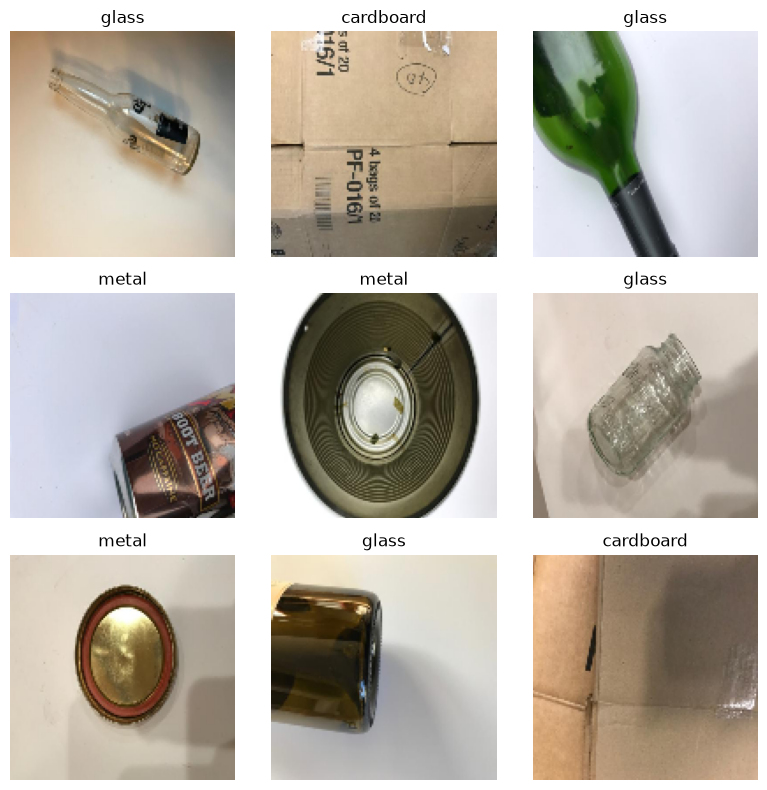

In [6]:
# Visualize a few sample images
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i])
    plt.title(CLASSES[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.savefig("../images/training_plots/sample_dataset_images.png")
plt.show()

In [7]:
# Save preprocessed arrays for use in the next notebook
np.save("../dataset/X_train.npy", X_train)
np.save("../dataset/X_val.npy", X_val)
np.save("../dataset/X_test.npy", X_test)
np.save("../dataset/y_train.npy", y_train)
np.save("../dataset/y_val.npy", y_val)
np.save("../dataset/y_test.npy", y_test)

print("Preprocessed data saved successfully.")

Preprocessed data saved successfully.
